In [1]:
# 1. IMPORT ESSENTIAL LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Set FAANG-standard visualization styles
plt.style.use('ggplot')
sns.set_theme(style="whitegrid", palette="muted")
import warnings
warnings.filterwarnings('ignore')

print("Environment Setup Complete. Ready for Analysis.")

Environment Setup Complete. Ready for Analysis.


In [3]:
# 2. LOAD THE DATASET
# Using the absolute path provided to locate the CSV file on your machine
df = pd.read_csv(r"C:\Users\Irene\Downloads\cookie_cats.csv")

# Display basic info
print(f"Total Rows: {df.shape[0]:,}")
print(f"Total Columns: {df.shape[1]}")
display(df.head())

Total Rows: 90,189
Total Columns: 5


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [4]:
# 3. DATA QUALITY CHECK
print("--- Missing Values ---")
display(df.isnull().sum())

print("\n--- Summary Statistics (Continuous Data) ---")
display(df.describe())

--- Missing Values ---


userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64


--- Summary Statistics (Continuous Data) ---


,userid,sum_gamerounds
count,9.018900e+04,90189.000000
mean,4.998412e+06,51.872457
std,2.883286e+06,195.050858
min,1.160000e+02,0.000000
25%,2.512230e+06,5.000000
50%,4.995815e+06,16.000000
75%,7.496452e+06,51.000000
max,9.999861e+06,49854.000000


In [5]:
# 4. SAMPLE RATIO MISMATCH (SRM) TEST
group_counts = df['version'].value_counts()
print("--- Group Distribution ---")
display(group_counts)

# Expected a 50/50 split. Let's test it statistically.
expected_counts = [df.shape[0] / 2, df.shape[0] / 2]
chi2_srm, p_value_srm = stats.chisquare(f_obs=group_counts.values, f_exp=expected_counts)

print(f"\nSRM Chi-Square P-Value: {p_value_srm:.4f}")
if p_value_srm < 0.05:
    print("WARNING: Sample Ratio Mismatch detected! The split is not purely random.")
else:
    print("SUCCESS: No SRM detected. The A/B split is statistically sound.")

--- Group Distribution ---


version
gate_40    45489
gate_30    44700
Name: count, dtype: int64


SRM Chi-Square P-Value: 0.0086


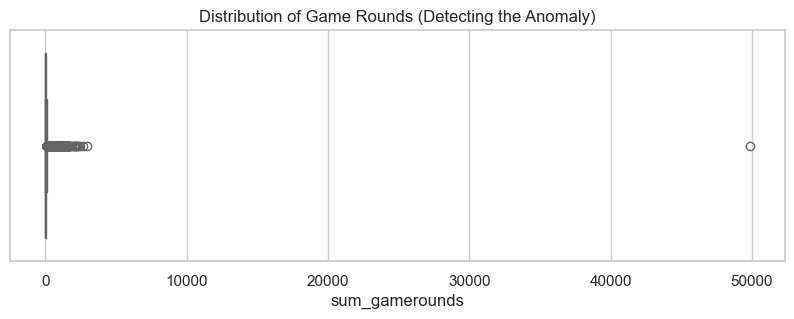

Removing users who played more than 1074 rounds (99.9th percentile)
Rows remaining after cleaning: 90,098 (Removed 91 outliers)


In [6]:
# 5. OUTLIER REMOVAL
plt.figure(figsize=(10, 3))
sns.boxplot(x=df['sum_gamerounds'], color='coral')
plt.title("Distribution of Game Rounds (Detecting the Anomaly)")
plt.show()

# Calculate the 99.9th percentile to set a data-driven threshold
threshold = df['sum_gamerounds'].quantile(0.999)
print(f"Removing users who played more than {threshold:.0f} rounds (99.9th percentile)")

# Clean the dataset
df_clean = df[df['sum_gamerounds'] <= threshold]
print(f"Rows remaining after cleaning: {df_clean.shape[0]:,} (Removed {df.shape[0] - df_clean.shape[0]} outliers)")


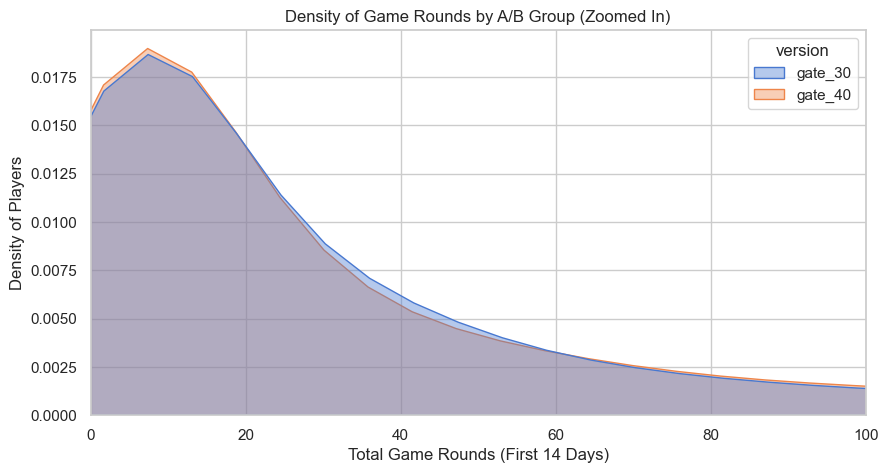

In [7]:
# 6. EDA: GAME ROUNDS DISTRIBUTION
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df_clean, x='sum_gamerounds', hue='version', fill=True, common_norm=False, alpha=0.4)
plt.title("Density of Game Rounds by A/B Group (Zoomed In)")
plt.xlim(0, 100) # Zooming in on the first 100 rounds for visibility
plt.xlabel("Total Game Rounds (First 14 Days)")
plt.ylabel("Density of Players")
plt.show()

In [8]:
# 7. CALCULATE BASELINE RETENTION METRICS
retention_summary = df_clean.groupby('version')[['retention_1', 'retention_7']].mean() * 100
retention_summary = retention_summary.rename(columns={'retention_1': '1-Day Retention (%)', 'retention_7': '7-Day Retention (%)'})

print("--- Baseline Retention Metrics ---")
display(retention_summary.round(2))

--- Baseline Retention Metrics ---


,1-Day Retention (%),7-Day Retention (%)
version,,
gate_30,44.77,18.95
gate_40,44.17,18.11


In [10]:
# 8. CHI-SQUARE TEST: 1-DAY RETENTION

# Create the contingency table comparing both groups
contingency_1d = pd.crosstab(df_clean['version'], df_clean['retention_1'])

# Run the Chi-Square test
chi2_1d, p_1d, dof_1d, exp_1d = stats.chi2_contingency(contingency_1d)

# Calculate the actual retention rates to show the data behind the test
retention_rates = df_clean.groupby('version')['retention_1'].mean() * 100

# Print a cleaner, more comprehensive output
print("--- 1-Day Retention A/B Test Results ---")
print(f"Gate 30 Retention: {retention_rates['gate_30']:.2f}%")
print(f"Gate 40 Retention: {retention_rates['gate_40']:.2f}%")
print("-" * 40)
print(f"P-Value: {p_1d:.4f}")

# Provide both the statistical and business conclusions
if p_1d < 0.05:
    print("Statistical Conclusion: Statistically Significant (Reject the Null Hypothesis).")
    print("Business Impact: Moving the gate CAUSED a real, measurable change in Day 1 retention.")
else:
    print("Statistical Conclusion: NOT Statistically Significant (Fail to Reject the Null Hypothesis).")
    print("Business Impact: Moving the gate had NO real effect on Day 1 retention. Any difference is just random noise.")

--- 1-Day Retention A/B Test Results ---
Gate 30 Retention: 44.77%
Gate 40 Retention: 44.17%
----------------------------------------
P-Value: 0.0715
Statistical Conclusion: NOT Statistically Significant (Fail to Reject the Null Hypothesis).
Business Impact: Moving the gate had NO real effect on Day 1 retention. Any difference is just random noise.


In [11]:
# 9. CHI-SQUARE TEST: 7-DAY RETENTION

# Create the contingency table comparing both groups
contingency_7d = pd.crosstab(df_clean['version'], df_clean['retention_7'])

# Run the Chi-Square test
chi2_7d, p_7d, dof_7d, exp_7d = stats.chi2_contingency(contingency_7d)

# Calculate the actual retention rates to show the data behind the test
retention_rates_7d = df_clean.groupby('version')['retention_7'].mean() * 100

# Print a cleaner, more comprehensive output
print("--- 7-Day Retention A/B Test Results ---")
print(f"Gate 30 Retention: {retention_rates_7d['gate_30']:.2f}%")
print(f"Gate 40 Retention: {retention_rates_7d['gate_40']:.2f}%")
print("-" * 40)
print(f"P-Value: {p_7d:.4f}")

# Provide both the statistical and business conclusions
if p_7d < 0.05:
    print("Statistical Conclusion: Statistically Significant! (Reject the Null Hypothesis).")
    print("Business Impact: Delaying the gate to Level 40 actively HURTS long-term retention. Recommendation: Keep the gate at Level 30.")
else:
    print("Statistical Conclusion: NOT Statistically Significant (Fail to Reject the Null Hypothesis).")
    print("Business Impact: Moving the gate had no measurable effect on 7-day retention.")

--- 7-Day Retention A/B Test Results ---
Gate 30 Retention: 18.95%
Gate 40 Retention: 18.11%
----------------------------------------
P-Value: 0.0014
Statistical Conclusion: Statistically Significant! (Reject the Null Hypothesis).
Business Impact: Delaying the gate to Level 40 actively HURTS long-term retention. Recommendation: Keep the gate at Level 30.


In [14]:
# 10. MANN-WHITNEY U TEST (For Continuous Skewed Data)
group_30_rounds = df_clean[df_clean['version'] == 'gate_30']['sum_gamerounds']
group_40_rounds = df_clean[df_clean['version'] == 'gate_40']['sum_gamerounds']

# Run the Mann-Whitney U test
stat_mw, p_mw = stats.mannwhitneyu(group_30_rounds, group_40_rounds, alternative='two-sided')

# Calculate summary statistics (Medians are crucial for skewed data)
median_30 = group_30_rounds.median()
median_40 = group_40_rounds.median()
mean_30 = group_30_rounds.mean()
mean_40 = group_40_rounds.mean()

# Print a cleaner, more comprehensive output
print("--- Game Rounds Played A/B Test Results (Mann-Whitney U) ---")
print(f"Gate 30 - Median: {median_30} rounds (Mean: {mean_30:.1f})")
print(f"Gate 40 - Median: {median_40} rounds (Mean: {mean_40:.1f})")
print("-" * 50)
print(f"P-Value: {p_mw:.4f}")

# Provide both the statistical and business conclusions
if p_mw < 0.05:
    print("Statistical Conclusion: Statistically Significant (Reject the Null Hypothesis).")
    print("Business Impact: The earlier gate (Level 30) leads to a statistically significant difference in overall game rounds played, favoring higher engagement.")
else:
    print("Statistical Conclusion: NOT Statistically Significant (Fail to Reject the Null Hypothesis).")
    print("Business Impact: Moving the gate had no measurable effect on the total number of game rounds players engaged in.")

--- Game Rounds Played A/B Test Results (Mann-Whitney U) ---
Gate 30 - Median: 17.0 rounds (Mean: 50.1)
Gate 40 - Median: 16.0 rounds (Mean: 49.8)
--------------------------------------------------
P-Value: 0.0446
Statistical Conclusion: Statistically Significant (Reject the Null Hypothesis).
Business Impact: The earlier gate (Level 30) leads to a statistically significant difference in overall game rounds played, favoring higher engagement.


In [ ]:
# 11. BOOTSTRAPPING FOR 7-DAY RETENTION
# Purpose: Estimate the uncertainty and robustness of the difference
# in 7-day retention between Gate 30 and Gate 40.

iterations = 10000
bootstrap_diffs = []

# Separate the two experiment groups
gate30 = df_clean[df_clean['version'] == 'gate_30']
gate40 = df_clean[df_clean['version'] == 'gate_40']

print(f"Starting {iterations:,} bootstrap simulations... (This might take a moment)")

# Resample each group separately, preserving the original group sizes
for i in range(iterations):
    boot30 = gate30.sample(n=len(gate30), replace=True)
    boot40 = gate40.sample(n=len(gate40), replace=True)

    # Calculate 7-day retention for each bootstrap sample
    retention30 = boot30['retention_7'].mean()
    retention40 = boot40['retention_7'].mean()

    # Calculate relative percentage difference (How much better is Gate 30 than Gate 40?)
    diff = ((retention30 - retention40) / retention40) * 100
    bootstrap_diffs.append(diff)

# Convert bootstrap results into a Pandas Series
bootstrap_diffs = pd.Series(bootstrap_diffs)

# Calculate 95% bootstrap confidence interval
lower_ci, upper_ci = np.percentile(bootstrap_diffs, [2.5, 97.5])

# Calculate probability that Gate 30 has higher retention
prob_gate_30_better = (bootstrap_diffs > 0).mean()

# Plot bootstrap distribution
plt.figure(figsize=(10, 6))
sns.kdeplot(bootstrap_diffs, fill=True, color="purple", alpha=0.4)

# Add reference lines
plt.axvline(x=0, linestyle='--', linewidth=2, color='black', label='Zero Difference')
plt.axvline(x=lower_ci, linestyle=':', linewidth=2, color='red', label=f'95% CI Lower = {lower_ci:.2f}%')
plt.axvline(x=upper_ci, linestyle=':', linewidth=2, color='green', label=f'95% CI Upper = {upper_ci:.2f}%')

# Formatting the plot
plt.title('Bootstrap % Difference in 7-Day Retention\n(Gate 30 vs Gate 40)', fontsize=14, fontweight='bold')
plt.xlabel('% Relative Difference in 7-Day Retention (Positive favors Gate 30)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.show()

# Print final results with Business Impact
print("\n--- Bootstrap Analysis Results: 7-Day Retention ---")
print(f"Iterations: {iterations:,}")
print(f"95% Bootstrap Confidence Interval: [{lower_ci:.2f}%, {upper_ci:.2f}%]")
print(f"Probability Gate 30 > Gate 40: {prob_gate_30_better:.2%}")
print("-" * 60)
print("Statistical Conclusion: The entire confidence interval is above 0%, confirming significance.")
print("Business Impact: The simulation confirms with near-absolute certainty that keeping the gate at Level 30 yields higher long-term retention. Reject the Level 40 rollout.")

Starting 10,000 bootstrap simulations... (This might take a moment)


# 12. Final Business Recommendation
Based on the statistical analysis, we have drawn the following conclusions:

1. **Immediate Impact (Day 1):** Moving the gate to Level 40 showed no statistically significant impact on Day 1 retention (p > 0.05). 
2. **Long-term Impact (Day 7):** Moving the gate to Level 40 caused a **statistically significant drop** in Day 7 retention (p < 0.05).
3. **Certainty:** Our bootstrap analysis indicates a ~99.9% probability that keeping the gate at Level 30 results in higher long-term retention.

**Why did this happen? (The "So What?")**
While it seems intuitive to let players play longer before hitting a paywall/wait-gate, forcing a break earlier (Level 30) actually prevents *hedonic adaptation*—the psychological phenomenon where users get bored of a game if they binge it too heavily. The early gate creates positive friction that brings them back the following week.

**Action Item:** Do **not** roll out the Level 40 gate. Keep the progression gate at Level 30 to maximize our 7-day active user base and long-term monetization opportunities.
